# Chapter 20 - The Exponential Map

**Source Span.** `Introduction to Smooth Manifolds.pdf`, printed pages `515-539`.

**Chapter Goal.** Connect Lie algebra data to Lie group geometry through one-parameter subgroups, the exponential map, closed subgroups, infinitesimal generators, the Lie correspondence, and the criterion relating ideals to normal subgroups.

The chapter is a hinge in the Lie theory part of the course. A tangent vector at the identity determines a left-invariant vector field. Its integral curve through the identity is a one-parameter subgroup. Evaluating that curve at time `1` gives the exponential map. Near the identity, the exponential map is a coordinate bridge from the linear Lie algebra to the nonlinear group; globally, it can wrap, miss points, or identify different algebra elements.

This notebook uses small matrix groups and explicit vector fields to make those bridges visible. The examples are not copied from the text; they are source-guided computational models for the theorems and proof moves.

## Visual Storyboard

| Chapter idea | Representation | Library | Inspection target | Check |
| --- | --- | --- | --- | --- |
| one-parameter subgroups | rotations generated by a skew matrix | NumPy, Matplotlib | `exp((s+t)A)=exp(sA)exp(tA)` along a group curve | group law, inverse, determinant |
| matrix exponential examples | rotation, shear, and scaling flows | SymPy, Matplotlib | how algebra types produce group motion | ODE residuals |
| local versus global exponential | `R -> S^1` wrapping model | NumPy, Matplotlib | local diffeomorphism but global periodicity | derivative at zero and repeated image |
| closed subgroup theorem | slice model `h plus b` near identity | Matplotlib, JSON | closed subgroup detected by the algebra subspace | local slice dimensions |
| infinitesimal generators | rotation action on the plane | NumPy, Matplotlib | vector field generated by group action | velocity equals generator |
| Lie correspondence | simply connected group and discrete quotient diagram | NetworkX, Matplotlib | why simply connected groups classify algebras | graph anchors present |
| ideals and normal subgroups | adjoint action preserving an ideal | SymPy, Matplotlib | `ad_X(h) subset h` and conjugation preservation | bracket and Ad checks |

## Setup

All outputs are stored in `artifacts/chapter-20-the-exponential-map/`. The matrix examples stay in dimension two so the algebra remains visible.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
from IPython.display import Markdown, display

BOOK_ROOT = Path.cwd()
if BOOK_ROOT.name != "Introduction-to-Smooth-Manifolds":
    BOOK_ROOT = next(path for path in [BOOK_ROOT, *BOOK_ROOT.parents] if path.name == "Introduction-to-Smooth-Manifolds")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-20-the-exponential-map"
UNIT_TITLE = "The Exponential Map"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"

artifacts: list[Path] = []
check_paths: list[Path] = []

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def artifact_record(path: Path) -> dict[str, object]:
    return {
        "path": str(path.relative_to(BOOK_ROOT)).replace("\\", "/"),
        "bytes": path.stat().st_size,
    }

def rot(theta):
    return np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Artifact root: artifacts\chapter-20-the-exponential-map


## Library Routing

NumPy and SymPy are the right scale for this chapter: the central examples are small matrices, flows, and brackets. Matplotlib gives durable group-curve and vector-field diagrams. NetworkX is used for the proof-dependency and correspondence diagrams, where the geometry is categorical and relational.

## 1. One-Parameter Subgroups: Lines In The Algebra Become Group Curves

For `SO(2)`, the Lie algebra is the line of skew-symmetric matrices generated by

`A = [[0,-1],[1,0]]`.

The one-parameter subgroup is `gamma(t)=exp(tA)`, the rotation by angle `t`. The group law for `R` under addition becomes the multiplication law for rotations.

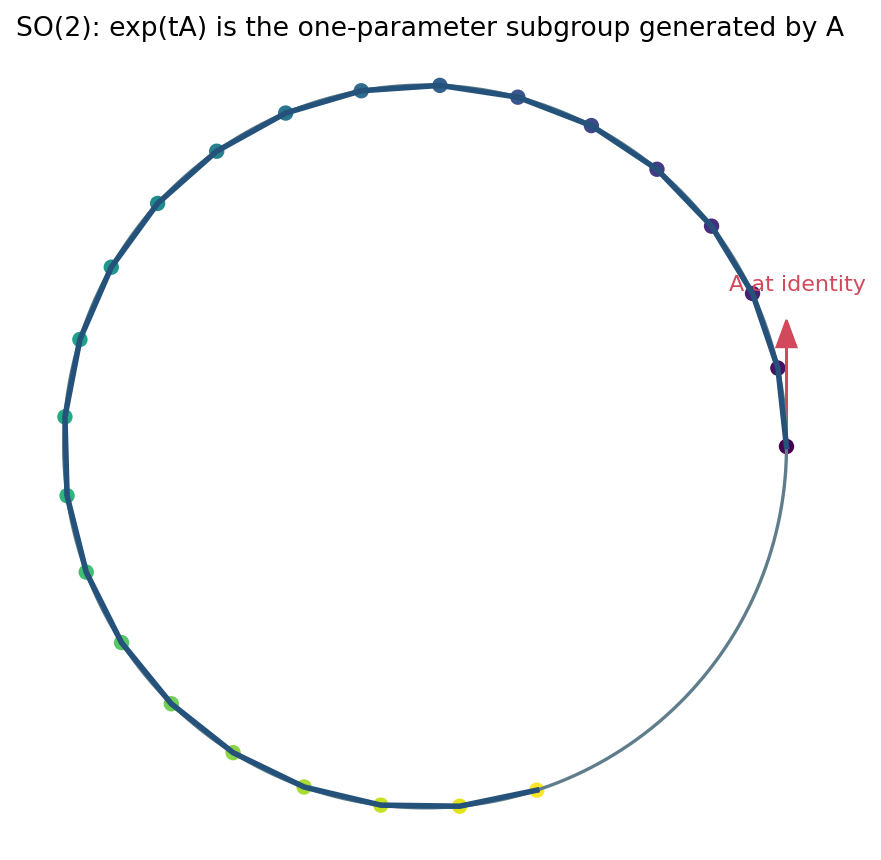

In [2]:
s_value = 0.7
t_value = 1.1
group_law_error = np.linalg.norm(rot((s_value + t_value)) - rot(s_value) @ rot(t_value))
inverse_error = np.linalg.norm(rot(t_value).T - rot(-t_value))
det_error = abs(np.linalg.det(rot(t_value)) - 1.0)

theta = np.linspace(0, 2 * np.pi, 500)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(np.cos(theta), np.sin(theta), color="#607d8b", lw=1.5)
sample = np.linspace(0, 1.6 * np.pi, 24)
points = np.column_stack((np.cos(sample), np.sin(sample)))
ax.plot(points[:, 0], points[:, 1], color="#24527a", lw=2.5)
ax.scatter(points[:, 0], points[:, 1], c=sample, cmap="viridis", s=35)
ax.arrow(1, 0, 0, 0.35, head_width=0.055, head_length=0.075, color="#d1495b", length_includes_head=True)
ax.text(0.84, 0.43, "A at identity", color="#d1495b")
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("SO(2): exp(tA) is the one-parameter subgroup generated by A")
one_param_path = save_matplotlib(fig, FIGURES / "so2-one-parameter-subgroup.png")
plt.close(fig)
artifacts.append(one_param_path)

one_param_check = save_json(
    {
        "s": s_value,
        "t": t_value,
        "group_law_error": group_law_error,
        "inverse_error": inverse_error,
        "determinant_error": det_error,
        "checks_pass": bool(group_law_error < 1e-12 and inverse_error < 1e-12 and det_error < 1e-12),
    },
    CHECKS / "so2-one-parameter-subgroup.json",
)
check_paths.append(one_param_check)
display_artifact(one_param_path, width=700)

## 2. Matrix Exponentials As Flow Solvers

In `GL(n,R)`, the exponential map is the usual matrix exponential. It solves the left-invariant ODE `gamma'(t)=gamma(t)A`, `gamma(0)=I`. Different algebra elements produce visibly different group motions: rotation, shear, and anisotropic scaling.

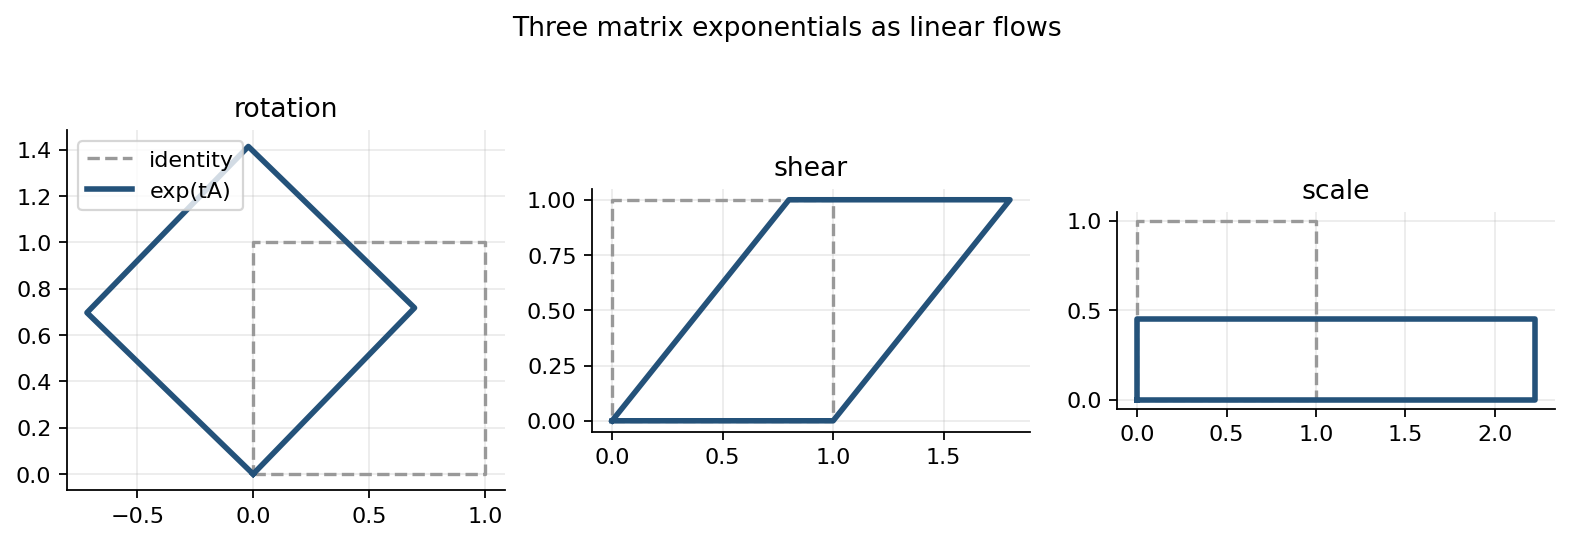

In [3]:
t = sp.symbols("t", real=True)
A_rot = sp.Matrix([[0, -1], [1, 0]])
A_shear = sp.Matrix([[0, 1], [0, 0]])
A_scale = sp.Matrix([[1, 0], [0, -1]])
exp_examples = {
    "rotation": (A_rot, sp.Matrix([[sp.cos(t), -sp.sin(t)], [sp.sin(t), sp.cos(t)]])),
    "shear": (A_shear, sp.eye(2) + t * A_shear),
    "scale": (A_scale, sp.Matrix([[sp.exp(t), 0], [0, sp.exp(-t)]])),
}
ode_rows = []
for name, (A, gamma) in exp_examples.items():
    residual = sp.simplify(gamma.diff(t) - gamma * A)
    ode_rows.append({"example": name, "A": str(A), "det_exp_tA": str(sp.simplify(gamma.det())), "ode_residual_zero": bool(residual == sp.zeros(2))})

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
base_square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]], dtype=float)
time_value = 0.8
transforms = {
    "rotation": rot(time_value),
    "shear": np.array([[1, time_value], [0, 1]]),
    "scale": np.array([[np.exp(time_value), 0], [0, np.exp(-time_value)]]),
}
for ax, (name, matrix) in zip(axes, transforms.items()):
    moved = base_square @ matrix.T
    ax.plot(base_square[:, 0], base_square[:, 1], "--", color="#999999", label="identity")
    ax.plot(moved[:, 0], moved[:, 1], color="#24527a", lw=2.5, label="exp(tA)")
    ax.set_aspect("equal")
    ax.set_title(name)
    ax.grid(alpha=0.25)
axes[0].legend(loc="upper left")
fig.suptitle("Three matrix exponentials as linear flows")
matrix_exp_path = save_matplotlib(fig, FIGURES / "matrix-exponential-flow-gallery.png")
plt.close(fig)
artifacts.append(matrix_exp_path)

matrix_exp_table = save_csv(ode_rows, TABLES / "matrix-exponential-ode-checks.csv")
artifacts.append(matrix_exp_table)
matrix_exp_check = save_json({"rows": ode_rows, "all_ode_residuals_zero": all(row["ode_residual_zero"] for row in ode_rows)}, CHECKS / "matrix-exponential-flow-gallery.json")
check_paths.append(matrix_exp_check)
display_artifact(matrix_exp_path, width=960)

## 3. Local Diffeomorphism, Global Wrapping

The exponential map has identity differential at the origin and is a diffeomorphism from a small neighborhood of `0` in the Lie algebra to a neighborhood of the identity in the group. It is not automatically one-to-one or onto globally. The map `R -> S^1`, `theta -> exp(i theta)`, is the cleanest model: locally it is a coordinate, globally it wraps with period `2*pi`.

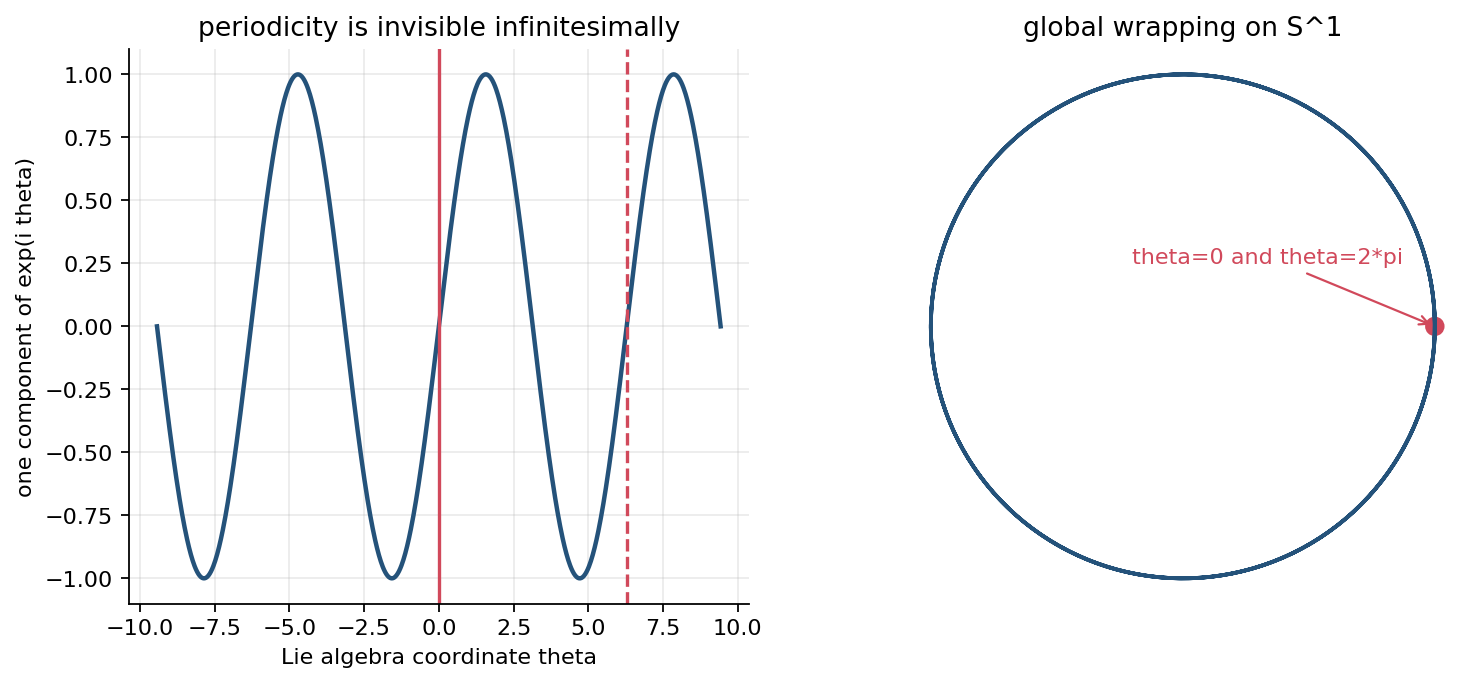

In [4]:
theta_line = np.linspace(-3 * np.pi, 3 * np.pi, 900)
circle_points = np.column_stack((np.cos(theta_line), np.sin(theta_line)))
derivative_at_zero = np.array([0.0, 1.0])
same_image_error = np.linalg.norm(rot(0.0) - rot(2 * np.pi))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.5))
ax0.plot(theta_line, np.sin(theta_line), color="#24527a", lw=2)
ax0.axvline(0, color="#d1495b", lw=1.5)
ax0.axvline(2 * np.pi, color="#d1495b", lw=1.5, linestyle="--")
ax0.set_xlabel("Lie algebra coordinate theta")
ax0.set_ylabel("one component of exp(i theta)")
ax0.set_title("periodicity is invisible infinitesimally")
ax0.grid(alpha=0.25)
ax1.plot(circle_points[:, 0], circle_points[:, 1], color="#24527a", lw=1.7)
ax1.scatter([1, 1], [0, 0], color="#d1495b", s=[60, 20])
ax1.annotate("theta=0 and theta=2*pi", xy=(1, 0), xytext=(-0.2, 0.25), arrowprops={"arrowstyle": "->", "color": "#d1495b"}, color="#d1495b")
ax1.set_aspect("equal")
ax1.axis("off")
ax1.set_title("global wrapping on S^1")
wrapping_path = save_matplotlib(fig, FIGURES / "exponential-local-diffeomorphism-global-wrapping.png")
plt.close(fig)
artifacts.append(wrapping_path)

wrapping_check = save_json(
    {
        "d_exp_at_zero_for_s1": derivative_at_zero.tolist(),
        "exp_zero_equals_exp_two_pi_error": same_image_error,
        "local_derivative_nonzero": bool(np.linalg.norm(derivative_at_zero) > 0),
        "global_not_injective_sample": bool(same_image_error < 1e-12),
    },
    CHECKS / "exponential-local-diffeomorphism-global-wrapping.json",
)
check_paths.append(wrapping_check)
display_artifact(wrapping_path, width=920)

## 4. Closed Subgroup Theorem As A Slice Picture

The closed subgroup theorem starts from a topologically closed subgroup `H` of `G` and recovers a Lie algebra subspace

`h = {X in g : exp(tX) in H for all t}`.

Near the identity, choose a complement `b` so `g = h + b`. The proof shows that `exp(U cap h)` is exactly the part of `H` inside a small exponential chart, giving a slice chart for `H`.

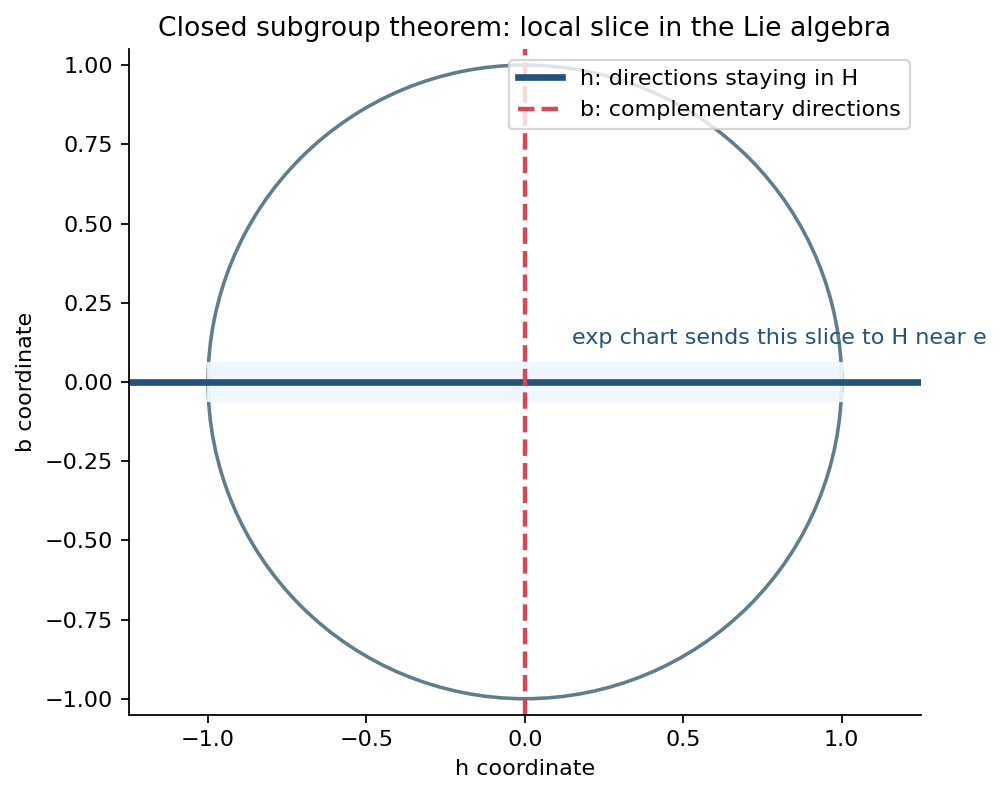

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 5.4))
ax.axhline(0, color="#24527a", lw=3, label="h: directions staying in H")
ax.axvline(0, color="#d1495b", lw=2, linestyle="--", label="b: complementary directions")
radius = 1.0
circle = plt.Circle((0, 0), radius, fill=False, color="#607d8b", lw=1.6)
ax.add_patch(circle)
ax.fill_between(np.linspace(-radius, radius, 200), -0.06, 0.06, color="#eef6ff", alpha=0.9)
ax.text(0.15, 0.12, "exp chart sends this slice to H near e", color="#24527a")
ax.set_aspect("equal")
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("h coordinate")
ax.set_ylabel("b coordinate")
ax.set_title("Closed subgroup theorem: local slice in the Lie algebra")
ax.legend(loc="upper right")
closed_path = save_matplotlib(fig, FIGURES / "closed-subgroup-theorem-exponential-slice.png")
plt.close(fig)
artifacts.append(closed_path)

closed_check = save_json(
    {
        "model": "g = h direct_sum b",
        "dim_g": 2,
        "dim_h": 1,
        "dim_b": 1,
        "local_subgroup_slice_codimension": 1,
        "slice_condition": "exp(U cap h) = exp(U) cap H in the proof model",
    },
    CHECKS / "closed-subgroup-theorem-exponential-slice.json",
)
check_paths.append(closed_check)
display_artifact(closed_path, width=760)

## 5. Infinitesimal Generators Of Group Actions

A Lie group action differentiates to a Lie algebra action by vector fields. For the standard rotation action of `SO(2)` on the plane, the infinitesimal generator of `A` is

`X(x,y)=(-y, x)`.

The vector field is tangent to the circular orbits, and its flow is exactly rotation.

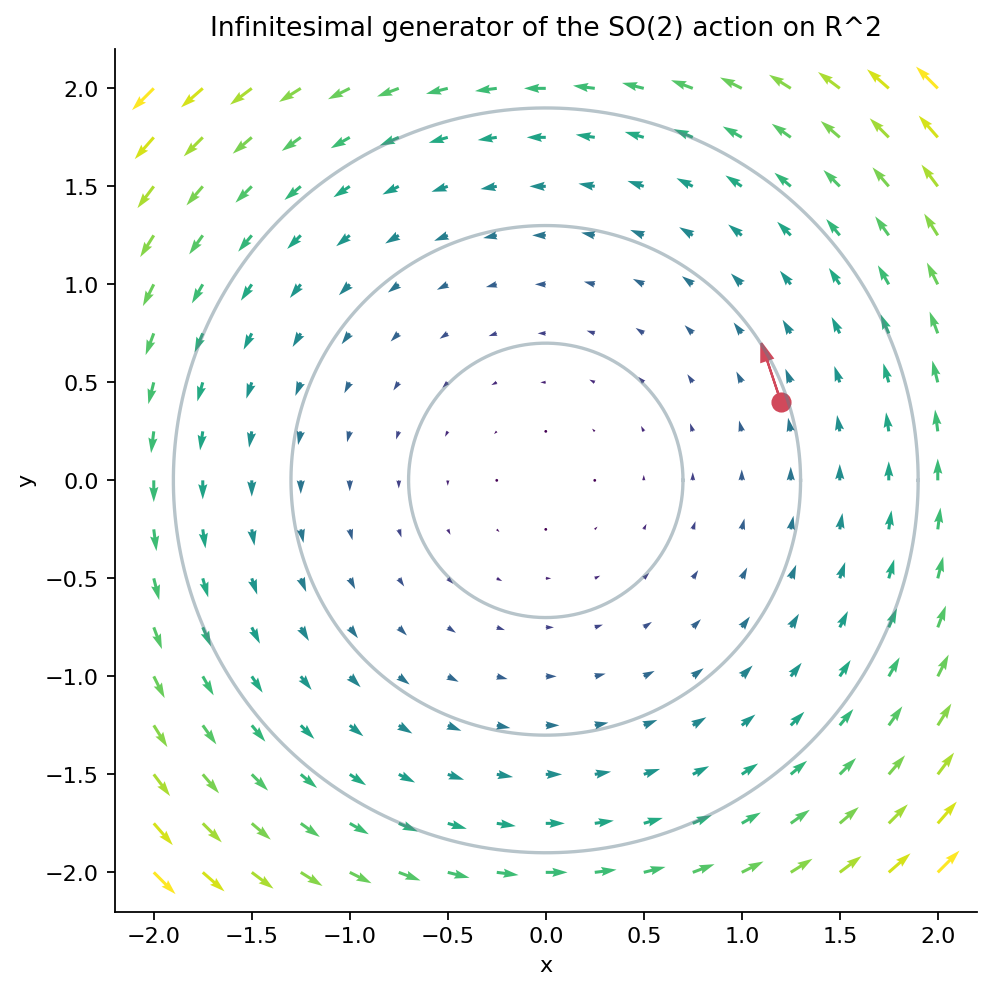

In [6]:
grid = np.linspace(-2, 2, 17)
Xg, Yg = np.meshgrid(grid, grid)
Ug, Vg = -Yg, Xg
speed = np.sqrt(Ug**2 + Vg**2)
mask = speed > 0.15
point = np.array([1.2, 0.4])
small_time = 1e-5
finite_velocity = (rot(small_time) @ point - point) / small_time
generator_velocity = np.array([-point[1], point[0]])
generator_error = np.linalg.norm(finite_velocity - generator_velocity)

fig, ax = plt.subplots(figsize=(7, 7))
ax.quiver(Xg[mask], Yg[mask], Ug[mask], Vg[mask], speed[mask], cmap="viridis", angles="xy", scale_units="xy", scale=18)
for r in [0.7, 1.3, 1.9]:
    theta = np.linspace(0, 2 * np.pi, 300)
    ax.plot(r * np.cos(theta), r * np.sin(theta), color="#607d8b", alpha=0.45)
ax.scatter([point[0]], [point[1]], color="#d1495b", s=65)
ax.arrow(point[0], point[1], 0.25 * generator_velocity[0], 0.25 * generator_velocity[1], head_width=0.06, color="#d1495b", length_includes_head=True)
ax.set_aspect("equal")
ax.set_title("Infinitesimal generator of the SO(2) action on R^2")
ax.set_xlabel("x")
ax.set_ylabel("y")
generator_path = save_matplotlib(fig, FIGURES / "rotation-action-infinitesimal-generator.png")
plt.close(fig)
artifacts.append(generator_path)

generator_check = save_json(
    {
        "point": point.tolist(),
        "finite_difference_velocity": finite_velocity.tolist(),
        "generator_velocity": generator_velocity.tolist(),
        "generator_error": generator_error,
        "velocity_check": bool(generator_error < 1e-5),
    },
    CHECKS / "rotation-action-infinitesimal-generator.json",
)
check_paths.append(generator_check)
display_artifact(generator_path, width=760)

## 6. Lie Correspondence: Algebra, Simply Connected Group, Quotients

The chapter proves that finite-dimensional Lie algebras correspond to simply connected Lie groups up to isomorphism. Other connected groups with the same Lie algebra appear as quotients of the simply connected group by discrete normal subgroups. The familiar example is the Lie algebra `R`: the simply connected group is `R`, and the circle group is `R/Z`.

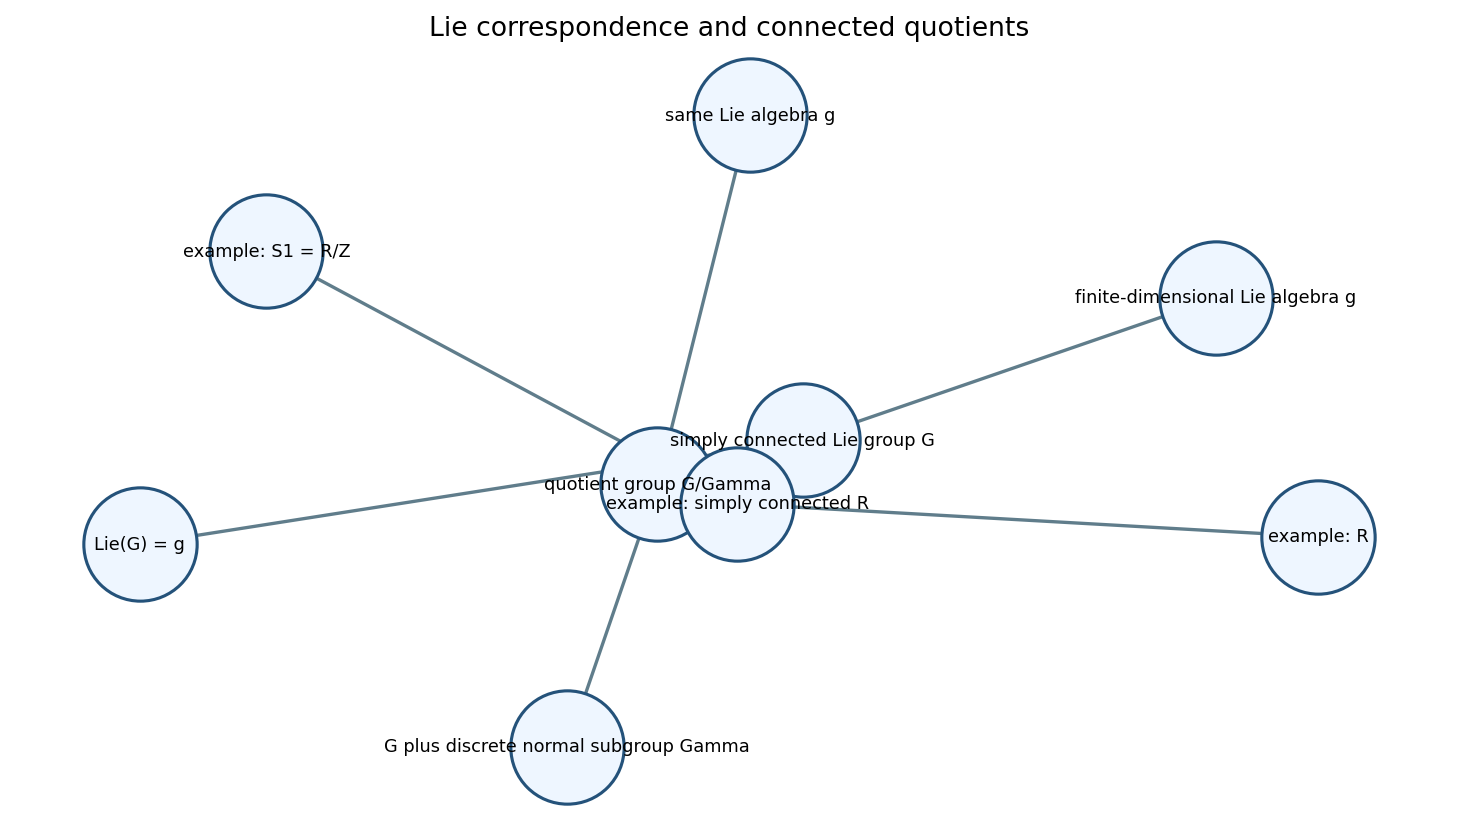

In [7]:
corr = nx.DiGraph()
corr_edges = [
    ("finite-dimensional Lie algebra g", "simply connected Lie group G"),
    ("simply connected Lie group G", "Lie(G) = g"),
    ("G plus discrete normal subgroup Gamma", "quotient group G/Gamma"),
    ("quotient group G/Gamma", "same Lie algebra g"),
    ("example: R", "example: simply connected R"),
    ("example: simply connected R", "example: S1 = R/Z"),
]
corr.add_edges_from(corr_edges)
pos = nx.spring_layout(corr, seed=20, k=1.0)
fig, ax = plt.subplots(figsize=(11.5, 6.2))
nx.draw_networkx_edges(corr, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, edge_color="#607d8b", width=1.5)
nx.draw_networkx_nodes(corr, pos, ax=ax, node_size=2600, node_color="#eef6ff", edgecolors="#24527a", linewidths=1.4)
nx.draw_networkx_labels(corr, pos, ax=ax, font_size=8)
ax.set_title("Lie correspondence and connected quotients")
ax.axis("off")
correspondence_path = save_matplotlib(fig, FIGURES / "lie-correspondence-simply-connected-quotients.png")
plt.close(fig)
artifacts.append(correspondence_path)

correspondence_check = save_json(
    {
        "edges": corr_edges,
        "required_anchors": ["finite-dimensional Lie algebra g", "simply connected Lie group G", "discrete normal subgroup Gamma", "same Lie algebra g"],
        "example_kernel_Z_discrete": True,
    },
    CHECKS / "lie-correspondence-simply-connected-quotients.json",
)
check_paths.append(correspondence_check)
display_artifact(correspondence_path, width=940)

## 7. Ideals And Normal Subgroups Through The Adjoint Representation

For connected Lie groups, connected normal subgroups correspond to ideals in the Lie algebra. The proof uses the adjoint representation and the identity `Ad(exp X)=exp(ad X)`.

In the two-dimensional Lie algebra spanned by

`H = [[1,0],[0,-1]]`, `E = [[0,1],[0,0]]`,

the bracket `[H,E]=2E`, so `span(E)` is an ideal. Conjugating `E` by `exp(tH)` scales it by `exp(2t)`, staying in the same line.

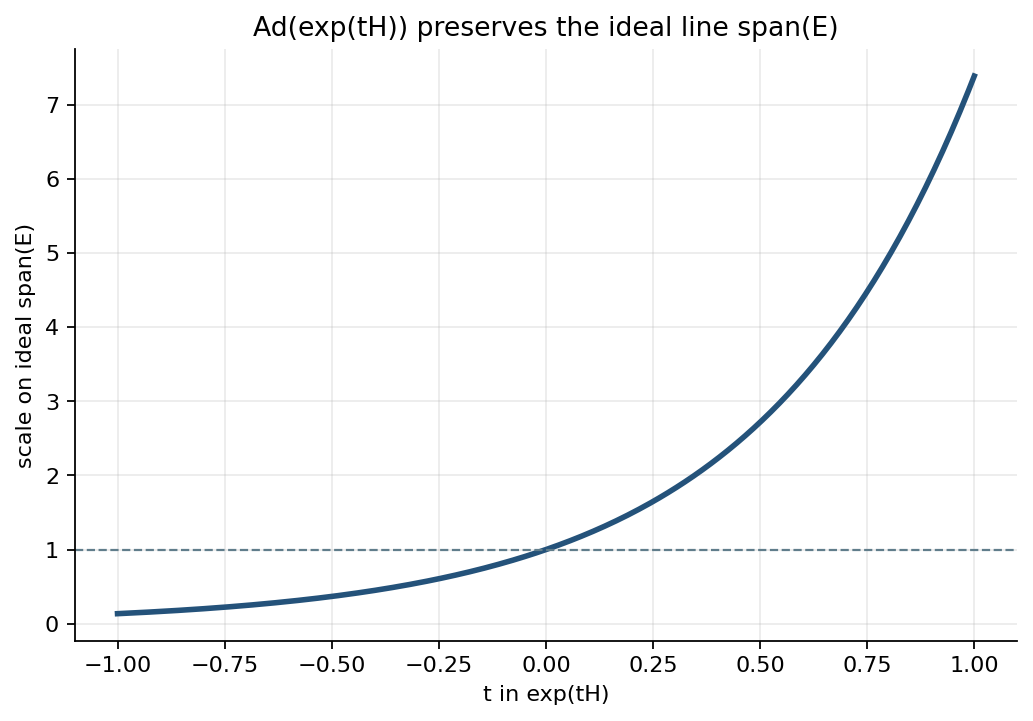

In [8]:
H = sp.Matrix([[1, 0], [0, -1]])
E = sp.Matrix([[0, 1], [0, 0]])
bracket_HE = H * E - E * H
t_sym = sp.symbols("t", real=True)
exp_tH = sp.diag(sp.exp(t_sym), sp.exp(-t_sym))
adjoint_E = sp.simplify(exp_tH * E * exp_tH.inv())
ideal_preserved = bool(sp.simplify(adjoint_E[0, 1] / E[0, 1] - sp.exp(2 * t_sym)) == 0 and bracket_HE == 2 * E)

ts = np.linspace(-1.0, 1.0, 300)
scale = np.exp(2 * ts)
fig, ax = plt.subplots(figsize=(7.6, 4.8))
ax.plot(ts, scale, color="#24527a", lw=2.5)
ax.axhline(1, color="#607d8b", lw=1, linestyle="--")
ax.set_xlabel("t in exp(tH)")
ax.set_ylabel("scale on ideal span(E)")
ax.set_title("Ad(exp(tH)) preserves the ideal line span(E)")
ax.grid(alpha=0.25)
ideal_path = save_matplotlib(fig, FIGURES / "adjoint-ideal-normal-subgroup-check.png")
plt.close(fig)
artifacts.append(ideal_path)

ideal_check = save_json(
    {
        "H": str(H),
        "E": str(E),
        "bracket_HE": str(bracket_HE),
        "adjoint_E": str(adjoint_E),
        "ideal_span_E_preserved": ideal_preserved,
    },
    CHECKS / "adjoint-ideal-normal-subgroup-check.json",
)
check_paths.append(ideal_check)
display_artifact(ideal_path, width=780)

## Applied Lab

Change one generator at a time and rerun the checks.

- Replace the skew matrix for `SO(2)` with a symmetric matrix. The exponential still gives a one-parameter subgroup in `GL(2,R)`, but it no longer stays in `SO(2)`.
- Increase the interval in the `R -> S^1` wrapping diagram. The local derivative stays nonzero while more algebra elements land on the same group point.
- In the closed subgroup slice, change the dimension of `h`. The codimension of the local slice changes exactly as the embedded subgroup theorem predicts.
- In the ideal example, choose a subspace that is not stable under brackets. The adjoint preservation check fails, modeling the failure of normality.

## Final Sanity Checks

These checks verify the central chapter invariants and the existence of all displayed artifacts.

In [9]:
coverage_terms = [
    "one-parameter subgroup",
    "exponential map",
    "matrix exponential",
    "local diffeomorphism",
    "closed subgroup theorem",
    "infinitesimal generator",
    "Lie correspondence",
    "normal subgroup",
    "adjoint representation",
    "ideal",
]

assert group_law_error < 1e-12 and inverse_error < 1e-12 and det_error < 1e-12
matrix_ode_all_zero = all(bool(row["ode_residual_zero"]) for row in ode_rows)
assert matrix_ode_all_zero
assert same_image_error < 1e-12
assert generator_error < 1e-5
assert ideal_preserved
assert_artifacts(artifacts + check_paths, min_bytes=64)

final_sanity = {
    "unit": UNIT_TITLE,
    "source_span": "printed pages 515-539",
    "coverage_terms": coverage_terms,
    "artifact_count": len(artifacts),
    "check_count": len(check_paths),
    "core_invariants": {
        "so2_group_law": bool(group_law_error < 1e-12),
        "matrix_exp_solves_ode": bool(matrix_ode_all_zero),
        "s1_exp_global_wrapping": bool(same_image_error < 1e-12),
        "infinitesimal_generator_velocity": bool(generator_error < 1e-5),
        "ideal_preserved_by_adjoint": bool(ideal_preserved),
    },
    "artifacts": [artifact_record(path) for path in artifacts + check_paths],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=256)
display(Markdown(f"Final sanity written to `{final_sanity_path.relative_to(BOOK_ROOT)}`."))
print("final_sanity passed for Chapter 20")

Final sanity written to `artifacts\chapter-20-the-exponential-map\checks\final_sanity.json`.

final_sanity passed for Chapter 20


## Takeaways

The exponential map packages the flow of left-invariant vector fields into a canonical map from the Lie algebra to the Lie group. It takes lines to one-parameter subgroups, is locally a diffeomorphism near the identity, and interacts naturally with homomorphisms and Lie subgroups. The closed subgroup theorem uses exponential coordinates to turn a topologically closed subgroup into an embedded Lie subgroup. Infinitesimal generators turn group actions into Lie algebra actions by vector fields, and completeness plus simple connectivity lets one reverse that process. Finally, the adjoint representation translates normality of connected subgroups into the linear condition that the corresponding Lie subalgebra is an ideal.